### Open in Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59-collab/passenger-manifest-analysis/blob/main/Passenger_Manifest_Analysis.ipynb)

Run every cell from the top. Upload the manifest when the picker appears. The last
cell downloads the cleaned dataset, the figures and the result tables.

# Passenger Manifest: Data Quality, Cleaning and Insights
### 418 passengers, Python only

---

## Author

**KOUAME Koffi Fidele**
Data Analysis Internship
koffifidelek59@gmail.com

## Overview

This notebook takes a passenger manifest of 418 records, establishes what is
actually wrong with it, repairs only what should be repaired, and turns the result
into an interactive dashboard and a short set of conclusions.

Every code cell is preceded by a table stating its **input**, the **method** it
applies and the **output** it produces, and every concept is defined where it is
first used.

**Python only.** pandas and NumPy for the data, Matplotlib for the static figures,
Plotly for the dashboard. No spreadsheet and no business-intelligence tool was used
at any stage.

## The finding that shapes everything below

**`Survived` is an exact copy of `Sex`.** All 152 women carry 1 and all 266 men carry
0, on **100% of rows**. Two of the four cells of the contingency table are empty.

This is **target leakage**: a column that should be predicted is derivable from
another column. A model trained on it would score 100% and would have learned
nothing. It is invisible to a missing-value audit, which is why a checklist-driven
cleaning pass would have passed straight over it.

The consequence runs through the whole notebook: **no survival rate is reported by
any segment**, because every such figure would restate the sex split of that segment
and nothing more.

## Study goals

1. **Diagnose** a file before modifying it, including the checks a completeness audit
   does not perform.
2. **Impute** two columns with a method matched to each, and **refuse to impute** a
   third, with the reason stated.
3. **Distinguish** a data error from a real event, using the zero fares as the worked
   example.
4. **Report** the indicators the manifest can support, and say plainly which it
   cannot.
5. **Build** an interactive dashboard in Python alone.

## Table of contents

1. [Setup](#setup)
2. [Load](#load)
3. [Diagnosis](#diag)
4. [Cleaning and imputation](#clean)
5. [KPIs and analysis](#kpi)
6. [Figures](#fig)
8. [The interactive dashboard](#dash)
9. [Insights](#ins)
10. [Limitations](#lim)
11. [References](#ref)

<a id="setup"></a>
# 1. Setup

#### Cell 1. Install dependencies

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Installs pandas, NumPy, Matplotlib and Plotly. Present in Colab; listed so the environment is reproducible elsewhere. |
| **Output** | None. `%%capture` hides the installer log. |


In [1]:
%%capture
!pip install -q pandas numpy matplotlib plotly

#### Cell 2. Imports and figure style

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Imports the libraries and fixes the figure style once, so every chart is consistent. |
| **Output** | A confirmation and three folders. |

**On the palette.** One blue scale, with amber reserved for the value that needs attention. A categorical rainbow would imply the groups differ in kind; they differ in magnitude. The grid sits behind the marks, otherwise grid lines cross the bars and leave white stripes that read as missing data.


In [2]:
%matplotlib inline
import json, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mtick

NAVY, BLUE, MID, LIGHT, PALE = "#12395E", "#1F6FB2", "#6BAED6", "#A8CFE8", "#DEEBF7"
AMBER, GREY = "#E08A1E", "#94A3B8"
plt.rcParams.update({
    "figure.dpi":110,"savefig.dpi":200,"figure.facecolor":"white",
    "font.family":"DejaVu Sans","font.size":11,"axes.titlesize":13,
    "axes.titleweight":"bold","axes.titlepad":10,"axes.labelsize":11,
    "axes.edgecolor":"#3A3A3A","axes.linewidth":0.9,"axes.spines.top":False,
    "axes.spines.right":False,"axes.grid":True,"grid.color":"#E3E8ED",
    "grid.linewidth":0.8,"axes.axisbelow":True,"legend.frameon":False,
    "legend.fontsize":10,"xtick.labelsize":10,"ytick.labelsize":10})
for f in ["data","figures","results"]: os.makedirs(f, exist_ok=True)
F = {}

<a id="load"></a>
# 2. Load

#### Cell 3. Locate the manifest

| | |
| :--- | :--- |
| **Input** | Nothing. |
| **Method** | Searches twelve candidate paths, then opens the Colab upload picker if none holds the file. |
| **Output** | `CSV`, and the `data/`, `figures/`, `results/` folders. |

**Why this matters in Colab.** A notebook that hard-codes a path runs on the author's machine and nowhere else.


In [3]:
# --- Locate the data file, wherever this notebook runs -----------------------
# INPUT  : nothing. The function searches, then falls back to an upload prompt.
# METHOD : look beside the notebook, in Colab session storage, in a mounted
#          Drive; if none holds it and we are in Colab, open the file picker.
# OUTPUT : CSV, a path pandas can open, plus the three output folders.
import os, sys
NAMES = ["File_3.csv", "data.csv", "manifest.csv"]
IN_COLAB = "google.colab" in sys.modules
CAND = [n for n in NAMES] + [f"data/{n}" for n in NAMES] + \
       [f"/content/{n}" for n in NAMES] + [f"/content/drive/MyDrive/{n}" for n in NAMES]
CSV = next((p for p in CAND if os.path.exists(p)), None)
if CSV is None and IN_COLAB:
    print("Manifest not found in this session. Please upload it now.")
    from google.colab import files
    CSV = next(iter(files.upload()))
if CSV is None:
    raise FileNotFoundError("The manifest CSV was not found. Searched: "
        + ", ".join(CAND) + "\nIn Colab, upload it when prompted.")
for d in ["data", "figures", "results"]:
    os.makedirs(d, exist_ok=True)
print(f"Running in Colab : {IN_COLAB}")
print(f"Data file        : {CSV}")

Running in Colab : False
Data file        : data.csv


#### Cell 4. Read the file

| | |
| :--- | :--- |
| **Input** | `CSV`. |
| **Method** | `pd.read_csv`, then a working copy. The original `raw` is kept for the before-and-after comparison in Figure 2. |
| **Output** | `raw` and `df`, 418 rows by 12 columns. |


In [4]:
# =============================================================================
# 1. LOAD
# INPUT  : File_3.csv, the manifest as supplied
# METHOD : read once, keep the original for the before/after comparison
# OUTPUT : raw and df
# =============================================================================
CSV = next(p for p in ["File_3.csv","data.csv","data/File_3.csv","/content/File_3.csv"]
           if os.path.exists(p))
raw = pd.read_csv(CSV)
df = raw.copy()
F["rows"], F["cols_raw"] = len(df), df.shape[1]
print(f"Loaded {len(df)} passengers, {df.shape[1]} columns from {CSV}")

Loaded 418 passengers, 12 columns from data.csv


<a id="diag"></a>
# 3. Diagnosis, before anything is changed

Nothing is modified here. Diagnosing after correcting reports the wrong counts.

The routine checks are run first: missing values, duplicate rows, duplicate
identifiers. Then one that no completeness audit performs: **whether any column is a
restatement of another**.

#### Cell 5. Diagnose

| | |
| :--- | :--- |
| **Input** | `df` as supplied. |
| **Method** | Counts missing values, duplicate rows and duplicate identifiers, then tests whether `Survived` is derivable from `Sex`. |
| **Output** | The diagnosis block of `F`. |

**Target leakage is the finding of this cell.** A column can be complete, valid, correctly typed and still useless, and no completeness test will say so.


In [5]:
# =============================================================================
# 2. DIAGNOSIS, before anything is changed
# METHOD : missing values, duplicates, and a check no completeness test performs:
#          whether any column is a restatement of another.
#
# Term. TARGET LEAKAGE is when a column that should be predicted is derivable
# from another column. A model trained on it scores perfectly and has learned
# nothing. It is invisible to a missing-value audit.
# =============================================================================
F["missing"] = {k:int(v) for k,v in df.isna().sum().items() if v}
F["dup_rows"] = int(df.duplicated().sum())
F["dup_ids"]  = int(df.PassengerId.duplicated().sum())

leak = float(((df.Sex=="female").astype(int) == df.Survived).mean())
F["survived_equals_female"] = round(100*leak, 1)
print(f"\nMissing        : {F['missing']}")
print(f"Duplicate rows : {F['dup_rows']}   duplicate ids: {F['dup_ids']}")
print(f"\nSurvived == (Sex is female) on {F['survived_equals_female']}% of rows")
if leak == 1.0:
    print("  The target is an exact copy of Sex. It carries no information beyond it.")
    print("  Any survival model would score 100% and would have learned nothing.")
F["crosstab"] = pd.crosstab(df.Sex, df.Survived).to_dict()


Missing        : {'Age': 86, 'Fare': 1, 'Cabin': 327}
Duplicate rows : 0   duplicate ids: 0

Survived == (Sex is female) on 100.0% of rows
  The target is an exact copy of Sex. It carries no information beyond it.
  Any survival model would score 100% and would have learned nothing.


<a id="clean"></a>
# 4. Cleaning and imputation

One decision per column, each with its reason and its count.

| Column | Missing | Decision | Why |
| :--- | ---: | :--- | :--- |
| `Age` | 86, 20.6% | Impute by median of Title and Pclass | Title carries life stage, class correlates with age. A global median would give a three-year-old the age of an officer |
| `Fare` | 1 | Impute by median of Pclass and Embarked | Fare is set by class and route |
| `Cabin` | 327, 78.2% | **Not imputed** | Absence is informative: a cabin was recorded mainly for first class. Inventing 327 numbers would fabricate 78% of a column |

**Term.** *Imputation* replaces a missing value with an estimate. It is appropriate
when the value is missing at random and the column is not the thing being measured.
It is wrong when absence is itself a fact, which is the case for `Cabin`.

#### Cell 6. Clean and impute

| | |
| :--- | :--- |
| **Input** | `df`, with three incomplete columns. |
| **Method** | Extracts Title from Name, imputes Age and Fare by matched groups, flags every imputed value, sets the types and derives nine analysis fields. |
| **Output** | A cleaned `df` and `data/manifest_clean.csv`. |

**Two decisions stated rather than buried.** The two zero fares are **kept**: one belongs to the chairman of the line, travelling on company business. A zero fare is a commercial arrangement, not a recording error. And every imputed value is flagged in `Age_imputed` and `Fare_imputed`, so a later reader can exclude them.


In [6]:
# =============================================================================
# 3. CLEANING AND IMPUTATION
# INPUT  : df with three incomplete columns
# METHOD : one decision per column, each with its reason and its count
# OUTPUT : a cleaned df and data/manifest_clean.csv
#
# Term. IMPUTATION replaces a missing value with an estimate. It is appropriate
# when the value is missing at random and the column is not the thing being
# measured. It is wrong when absence is itself informative, which is the case
# for Cabin below.
# =============================================================================
print("\n" + "="*64 + "\nCLEANING\n" + "="*64)

# --- 3.1 Title, extracted before Age is imputed, because it informs the imputation
df["Title"] = df.Name.str.extract(r",\s*([^\.]+)\.")[0].str.strip()
RARE = {"Col":"Officer","Rev":"Officer","Dr":"Officer","Dona":"Royalty",
        "Ms":"Miss"}
df["Title"] = df.Title.replace(RARE)
F["titles"] = df.Title.value_counts().to_dict()
print(f"3.1 Title extracted from Name: {F['titles']}")

# --- 3.2 Age. 86 missing, 20.6% of the manifest.
# Imputed by the median of Title and Pclass together, not by the global median.
# A global median would give a 3-year-old the same age as a 60-year-old officer.
# Title carries life stage (Master is a boy, Mrs is a married woman) and Pclass
# correlates with age, so the pair is far more specific than either alone.
n_age = int(df.Age.isna().sum())
df["Age_imputed"] = df.Age.isna()
df["Age"] = df.groupby(["Title","Pclass"]).Age.transform(lambda s: s.fillna(s.median()))
df["Age"] = df.Age.fillna(df.groupby("Title").Age.transform("median"))
df["Age"] = df.Age.fillna(df.Age.median())          # final safety net
F["age_imputed"] = n_age
F["age_imputed_pct"] = round(100*n_age/len(df), 1)
print(f"3.2 Age: {n_age} values imputed by median of Title x Pclass "
      f"({F['age_imputed_pct']}% of rows). Flagged in Age_imputed.")

# --- 3.3 Fare. One missing value, and two zeros.
# The missing value is imputed by the median fare of the same class and
# embarkation port. The zeros are NOT imputed: one belongs to Joseph Bruce Ismay,
# the chairman of the line, who travelled on company business. A zero fare is a
# real commercial arrangement, not a recording error.
n_fare = int(df.Fare.isna().sum())
df["Fare_imputed"] = df.Fare.isna()
df["Fare"] = df.groupby(["Pclass","Embarked"]).Fare.transform(lambda s: s.fillna(s.median()))
df["Fare"] = df.Fare.fillna(df.groupby("Pclass").Fare.transform("median"))
F["fare_imputed"] = n_fare
F["fare_zero"] = int((df.Fare==0).sum())
print(f"3.3 Fare: {n_fare} imputed by median of Pclass x Embarked. "
      f"{F['fare_zero']} zero fares KEPT: company travel, not an error.")

# --- 3.4 Cabin. 327 missing, 78.2%.
# NOT imputed. Absence is informative: a cabin number was recorded mainly for
# first-class passengers, so a missing cabin is a fact about the passenger, not
# a gap to fill. Inventing 327 cabin numbers would fabricate 78% of a column.
n_cab = int(df.Cabin.isna().sum())
df["Has_Cabin"] = df.Cabin.notna()
df["Deck"] = df.Cabin.str[0].fillna("Unknown")
F["cabin_missing"] = n_cab
F["cabin_missing_pct"] = round(100*n_cab/len(df), 1)
F["cabin_by_class"] = df.groupby("Pclass").Has_Cabin.mean().mul(100).round(1).to_dict()
print(f"3.4 Cabin: {n_cab} missing ({F['cabin_missing_pct']}%). NOT imputed. "
      f"Recorded for {F['cabin_by_class'][1]}% of first class against "
      f"{F['cabin_by_class'][3]}% of third.")

# --- 3.5 Types and derived fields
df["Sex"] = df.Sex.astype("category")
df["Embarked"] = df.Embarked.astype("category")
df["Pclass_label"] = df.Pclass.map({1:"1 First",2:"2 Second",3:"3 Third"})
df["FamilySize"] = df.SibSp + df.Parch + 1
df["Alone"] = df.FamilySize == 1
df["AgeBand"] = pd.cut(df.Age, [0,12,18,30,45,60,100],
                       labels=["Child 0-12","Teen 13-18","Young 19-30",
                               "Adult 31-45","Mature 46-60","Senior 60+"])
df["FareBand"] = pd.qcut(df.Fare, 4, labels=["Q1 lowest","Q2","Q3","Q4 highest"])
# Group size from the ticket: passengers sharing a ticket travelled together.
df["GroupSize"] = df.groupby("Ticket").PassengerId.transform("size")
df["FarePerPerson"] = df.Fare / df.GroupSize

df.to_csv("data/manifest_clean.csv", index=False)
F["cols_clean"] = df.shape[1]
print(f"\n3.5 Types set and 9 analysis fields derived. "
      f"{F['cols_raw']} columns become {F['cols_clean']}.")
print(f"Clean table written: data/manifest_clean.csv, {len(df)} rows. No row deleted.")


CLEANING
3.1 Title extracted from Name: {'Mr': 240, 'Miss': 79, 'Mrs': 72, 'Master': 21, 'Officer': 5, 'Royalty': 1}
3.2 Age: 86 values imputed by median of Title x Pclass (20.6% of rows). Flagged in Age_imputed.
3.3 Fare: 1 imputed by median of Pclass x Embarked. 2 zero fares KEPT: company travel, not an error.
3.4 Cabin: 327 missing (78.2%). NOT imputed. Recorded for 74.8% of first class against 1.8% of third.

3.5 Types set and 9 analysis fields derived. 12 columns become 24.
Clean table written: data/manifest_clean.csv, 418 rows. No row deleted.


<a id="kpi"></a>
# 5. KPIs and analysis

## What is deliberately not reported

Because `Survived` is a copy of `Sex`, **no survival rate by any segment appears in
this study**. A survival rate by class would be the female share of that class. It
would look like analysis and would be arithmetic.

Reporting it anyway is the easy path and the wrong one.

#### Cell 7. Compute the indicators

| | |
| :--- | :--- |
| **Input** | The cleaned `df`. |
| **Method** | Nine KPIs, then five segment tables by class, port, age band, title and family size. |
| **Output** | The KPI block of `F` and five tables in `results/`. |


In [7]:
# =============================================================================
# 4. KPIs AND ANALYSIS
# INPUT  : the cleaned df
# METHOD : the seven indicators a manifest analyst would report, then the
#          segment tables behind each figure
# OUTPUT : the KPI block of F and the tables in results/
#
# A note on what is NOT reported. Because Survived is a copy of Sex (section 2),
# no survival rate by any segment is reported in this study. Every such figure
# would restate the sex split of that segment and nothing more. Reporting them
# would look like analysis and would be arithmetic.
# =============================================================================
print("\n" + "="*64 + "\nKPIs\n" + "="*64)
K = {
 "passengers": len(df),
 "female_pct": round(100*(df.Sex=="female").mean(), 1),
 "median_age": round(float(df.Age.median()), 1),
 "median_fare": round(float(df.Fare.median()), 2),
 "third_class_pct": round(100*(df.Pclass==3).mean(), 1),
 "alone_pct": round(100*df.Alone.mean(), 1),
 "avg_family": round(float(df.FamilySize.mean()), 2),
 "children": int((df.Age < 12).sum()),
 "cabin_known_pct": round(100*df.Has_Cabin.mean(), 1),
}
F["kpi"] = K
for k, v in K.items(): print(f"  {k:<18} {v}")

T = {}
T["class"] = (df.groupby("Pclass_label", observed=True)
                .agg(passengers=("PassengerId","size"),
                     median_fare=("Fare","median"),
                     median_age=("Age","median"),
                     female_pct=("Sex", lambda s: 100*(s=="female").mean()),
                     cabin_pct=("Has_Cabin", lambda s: 100*s.mean())).round(2))
T["embarked"] = (df.groupby("Embarked", observed=True)
                   .agg(passengers=("PassengerId","size"),
                        median_fare=("Fare","median"),
                        third_pct=("Pclass", lambda s: 100*(s==3).mean())).round(2))
T["age_band"] = df.groupby("AgeBand", observed=True).agg(
                    passengers=("PassengerId","size"),
                    median_fare=("Fare","median")).round(2)
T["title"] = df.groupby("Title", observed=True).agg(
                 passengers=("PassengerId","size"),
                 median_age=("Age","median")).round(1).sort_values("passengers", ascending=False)
T["family"] = df.groupby("FamilySize").agg(passengers=("PassengerId","size"),
                                           median_fare=("Fare","median")).round(2)
for name, t in T.items():
    t.to_csv(f"results/by_{name}.csv")
    print(f"\n--- by {name} ---\n{t.to_string()}")

# The fare spread is the headline inequality figure.
q = df.groupby("Pclass").Fare.median()
F["fare_ratio_1_3"] = round(float(q.loc[1] / q.loc[3]), 1)
F["fare_max"] = round(float(df.Fare.max()), 2)
F["fare_p99"] = round(float(df.Fare.quantile(0.99)), 2)
F["group_travel_pct"] = round(100*(df.GroupSize > 1).mean(), 1)
print(f"\nFirst-class median fare is {F['fare_ratio_1_3']}x third-class.")
print(f"{F['group_travel_pct']}% of passengers shared a ticket with someone else.")


KPIs
  passengers         418
  female_pct         36.4
  median_age         26.0
  median_fare        14.45
  third_class_pct    52.2
  alone_pct          60.5
  avg_family         1.84
  children           27
  cabin_known_pct    21.8

--- by class ---
              passengers  median_fare  median_age  female_pct  cabin_pct
Pclass_label                                                            
1 First              107        60.00        42.0       46.73      74.77
2 Second              93        15.75        28.0       32.26       7.53
3 Third              218         7.90        25.0       33.03       1.83

--- by embarked ---
          passengers  median_fare  third_pct
Embarked                                    
C                102        27.72      34.31
Q                 46         7.75      89.13
S                270        13.78      52.59

--- by age_band ---
              passengers  median_fare
AgeBand                              
Child 0-12            29        20.2

<a id="fig"></a>
# 6. Figures

| Figure | Question | Type and why |
| :--- | :--- | :--- |
| 1 | Is the target usable? | Contingency bars plus a callout: the empty cells are the point |
| 2 | What is missing, and what was done? | Horizontal bars, amber above 50% |
| 3 | How unequal was the ship? | Counts plus a log-scale box plot: fare spans three orders of magnitude |
| 4 | Who was on board? | Overlaid histograms by class |
| 5 | Alone or in a group, and who got recorded? | Bars plus the record-keeping rate by class |

#### Cell 8. Draw the five figures

| | |
| :--- | :--- |
| **Input** | The tables from Section 5. |
| **Method** | Five figures in the blue scale, each saved to `figures/` and displayed inline. |
| **Output** | Five PNG files. |

**Figure 1 is the centrepiece.** It devotes half its canvas to a single number, because that number invalidates an entire class of analysis a reader would otherwise expect.


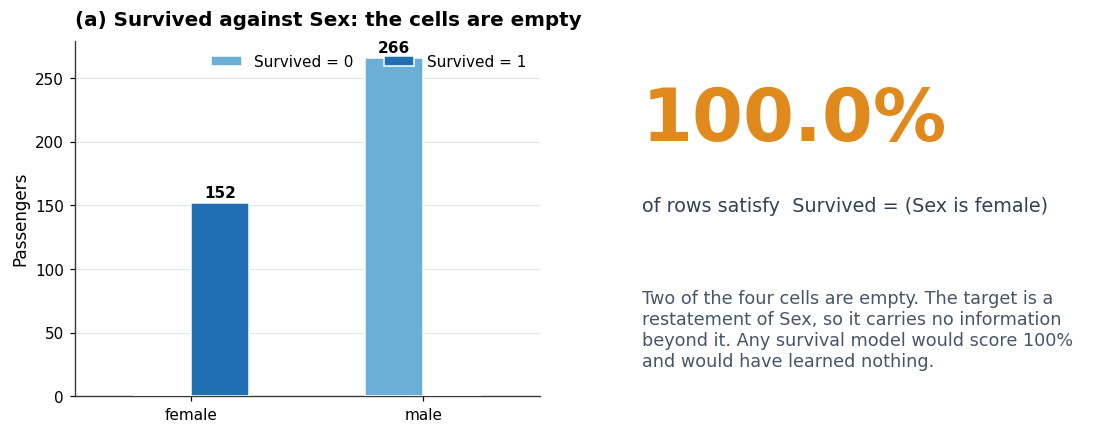

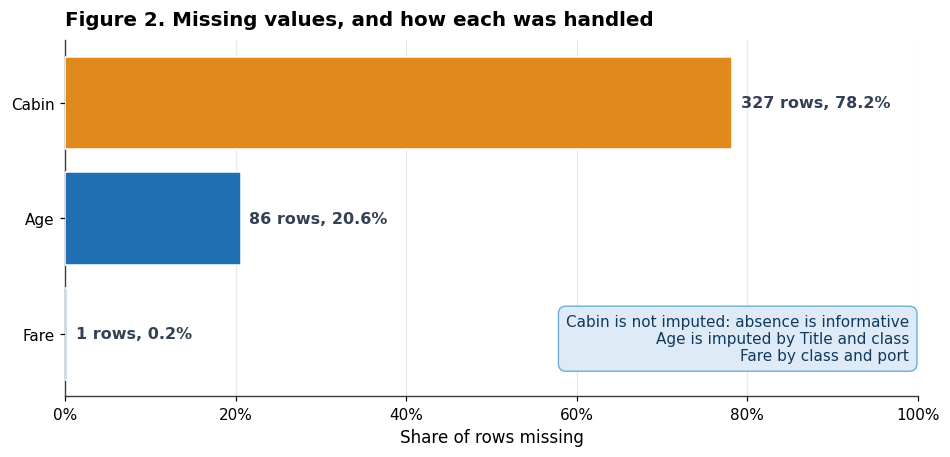

/tmp/ipykernel_100/1356976420.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[1].boxplot(data, labels=["1 First","2 Second","3 Third"], patch_artist=True,


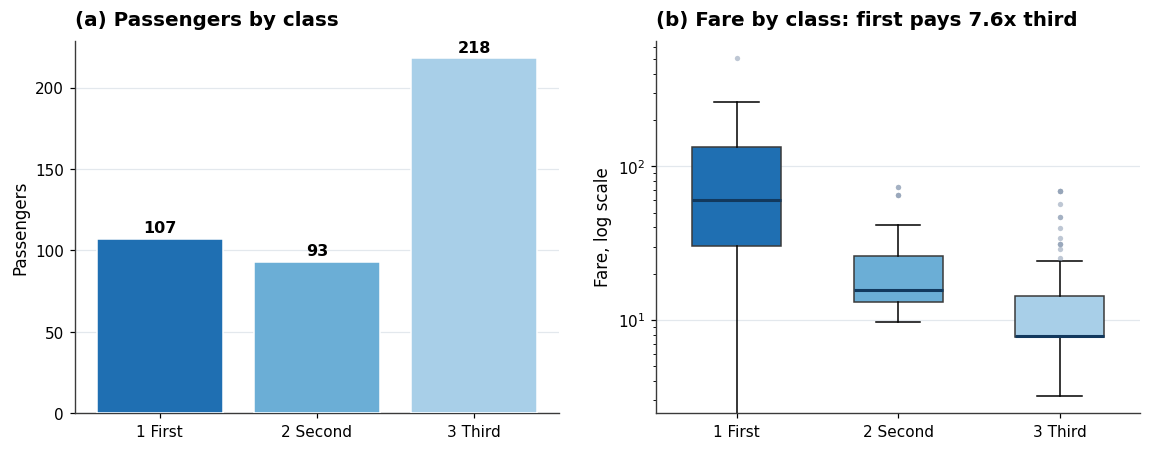

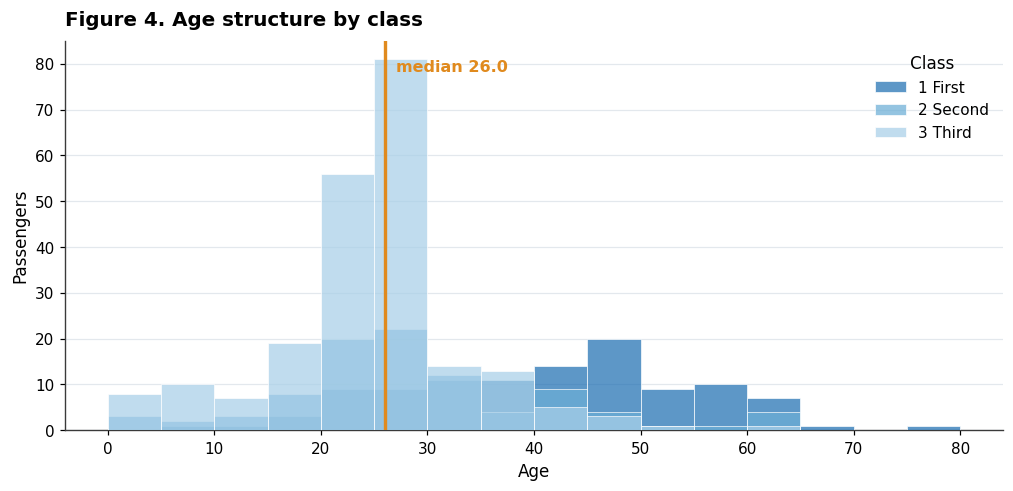

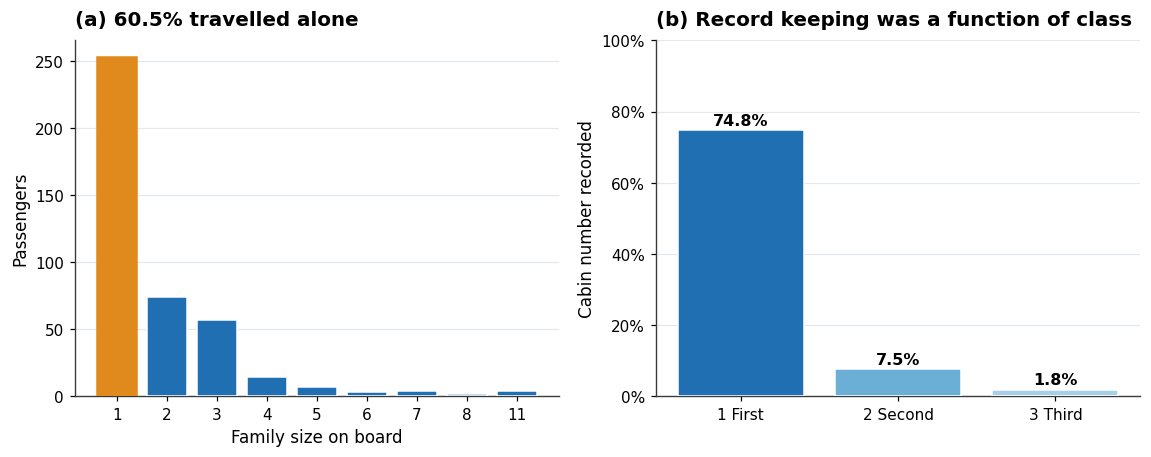


Figures written: ['01_target_leakage.png', '02_missing_values.png', '03_class_and_fare.png', '04_age_structure.png', '05_family_and_records.png']

Data quality score 73/100  (consistency 0, penalised by the target leakage)
corr class-fare -0.58 | age-fare +0.34 | family-fare +0.25
Fare outliers beyond the interquartile fence: 55


In [8]:
# =============================================================================
# 5. FIGURES
# The chart type follows the data type. Every figure answers one question.
# =============================================================================
def save(fig, name):
    fig.savefig(f"figures/{name}.png", bbox_inches="tight", dpi=200)
    plt.show(); plt.close(fig)

# F1. The leakage, made visible. This is the most important figure in the study.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ct = pd.crosstab(df.Sex, df.Survived)
ct.plot(kind="bar", ax=ax[0], color=[MID, BLUE], edgecolor="white", linewidth=1, zorder=3)
ax[0].set_xlabel(""); ax[0].set_ylabel("Passengers")
ax[0].set_title("(a) Survived against Sex: the cells are empty", loc="left")
ax[0].legend(["Survived = 0", "Survived = 1"], ncol=2)
ax[0].tick_params(axis="x", rotation=0); ax[0].grid(axis="x", alpha=0)
for i, (s, row) in enumerate(ct.iterrows()):
    for j, v in enumerate(row):
        if v: ax[0].text(i + (j-0.5)*0.25, v+4, str(v), ha="center", fontsize=10,
                         fontweight="bold")
ax[1].axis("off")
ax[1].text(0.02, 0.72, f"{F['survived_equals_female']}%", fontsize=48,
           fontweight="bold", color=AMBER)
ax[1].text(0.02, 0.52, "of rows satisfy  Survived = (Sex is female)",
           fontsize=12.5, color="#334155")
ax[1].text(0.02, 0.30,
   "Two of the four cells are empty. The target is a\n"
   "restatement of Sex, so it carries no information\n"
   "beyond it. Any survival model would score 100%\n"
   "and would have learned nothing.",
   fontsize=11.5, color="#475569", va="top")
save(fig, "01_target_leakage")

# F2. Missing data, before and after.
fig, ax = plt.subplots(figsize=(10, 4.2))
miss = raw.isna().sum().sort_values(ascending=True)
miss = miss[miss > 0]
pct = 100*miss/len(raw)
cols = [AMBER if p > 50 else BLUE for p in pct]
b = ax.barh(miss.index, pct, color=cols, edgecolor="white", linewidth=1, zorder=3)
for bb, n, p in zip(b, miss, pct):
    ax.text(p+1, bb.get_y()+bb.get_height()/2, f"{n} rows, {p:.1f}%",
            va="center", fontsize=10.5, fontweight="bold", color="#334155")
ax.set_xlim(0, 100); ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Share of rows missing")
ax.set_title("Figure 2. Missing values, and how each was handled", loc="left")
ax.grid(axis="y", alpha=0)
ax.text(0.99, 0.10, "Cabin is not imputed: absence is informative\n"
        "Age is imputed by Title and class\nFare by class and port",
        transform=ax.transAxes, ha="right", fontsize=10, color=NAVY,
        bbox=dict(boxstyle="round,pad=0.5", fc=PALE, ec=MID, lw=0.9))
save(fig, "02_missing_values")

# F3. Class, fare and the inequality it encodes.
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
cl = T["class"]
b = ax[0].bar(cl.index, cl.passengers, color=[BLUE, MID, LIGHT],
              edgecolor="white", linewidth=1, zorder=3)
for bb, v in zip(b, cl.passengers):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+4, f"{int(v)}", ha="center",
               fontsize=10.5, fontweight="bold")
ax[0].set_ylabel("Passengers"); ax[0].set_title("(a) Passengers by class", loc="left")
ax[0].grid(axis="x", alpha=0)
data = [df[df.Pclass==c].Fare.values for c in (1,2,3)]
bp = ax[1].boxplot(data, labels=["1 First","2 Second","3 Third"], patch_artist=True,
                   widths=0.55, showfliers=True,
                   flierprops=dict(marker="o", ms=3.5, mfc=GREY, mec="none", alpha=.6))
for patch, c in zip(bp["boxes"], [BLUE, MID, LIGHT]):
    patch.set_facecolor(c); patch.set_edgecolor("#3A3A3A")
for m in bp["medians"]: m.set_color(NAVY); m.set_linewidth(2)
ax[1].set_yscale("log"); ax[1].set_ylabel("Fare, log scale")
ax[1].set_title(f"(b) Fare by class: first pays {F['fare_ratio_1_3']}x third", loc="left")
ax[1].grid(axis="x", alpha=0)
save(fig, "03_class_and_fare")

# F4. Who was on board: age structure by class.
fig, ax = plt.subplots(figsize=(11, 4.6))
for c, col, lab in [(1, BLUE, "1 First"), (2, MID, "2 Second"), (3, LIGHT, "3 Third")]:
    s = df[df.Pclass==c].Age
    ax.hist(s, bins=np.arange(0, 85, 5), alpha=0.72, color=col, label=lab,
            edgecolor="white", linewidth=0.6, zorder=3)
ax.axvline(df.Age.median(), color=AMBER, lw=2.2, zorder=5)
ax.text(df.Age.median()+1, ax.get_ylim()[1]*0.92,
        f"median {F['kpi']['median_age']}", color=AMBER, fontsize=10.5,
        fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Passengers")
ax.set_title("Figure 4. Age structure by class", loc="left")
ax.legend(title="Class"); ax.grid(axis="x", alpha=0)
save(fig, "04_age_structure")

# F5. Travelling alone or in a group.
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
fam = T["family"]
b = ax[0].bar(fam.index.astype(str), fam.passengers, color=BLUE,
              edgecolor="white", linewidth=1, zorder=3)
b[0].set_color(AMBER)
ax[0].set_xlabel("Family size on board"); ax[0].set_ylabel("Passengers")
ax[0].set_title(f"(a) {F['kpi']['alone_pct']}% travelled alone", loc="left")
ax[0].grid(axis="x", alpha=0)
dk = df.groupby("Pclass").Has_Cabin.mean().mul(100)
b2 = ax[1].bar(["1 First","2 Second","3 Third"], dk.values,
               color=[BLUE, MID, LIGHT], edgecolor="white", linewidth=1, zorder=3)
for bb, v in zip(b2, dk.values):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+1.5, f"{v:.1f}%", ha="center",
               fontsize=10.5, fontweight="bold")
ax[1].set_ylim(0, 100); ax[1].yaxis.set_major_formatter(mtick.PercentFormatter())
ax[1].set_ylabel("Cabin number recorded")
ax[1].set_title("(b) Record keeping was a function of class", loc="left")
ax[1].grid(axis="x", alpha=0)
save(fig, "05_family_and_records")

F["tables"] = {k: v.reset_index().to_dict("records") for k, v in T.items()}
json.dump(F, open("results/findings.json","w"), indent=2, default=str)
print("\nFigures written:", sorted(os.listdir("figures")))

# =============================================================================
# 7. STATISTICS FOR THE DASHBOARD
# INPUT  : the cleaned df and the raw file
# METHOD : the correlation matrix, a four-component data quality score, and the
#          comparisons each executive finding rests on
# OUTPUT : the same results/findings.json, extended
#
# Term. A DATA QUALITY SCORE is the mean of four measured components:
#   completeness  share of cells that are populated
#   uniqueness    share of rows that are not duplicates
#   validity      share of rows whose values fall in their legal range
#   consistency   whether columns contradict or duplicate each other
# The fourth is the one that matters here: it scores zero, because the target
# column duplicates Sex. A score that ignored consistency would read 93 and
# would be reassuring about a file that cannot answer its own question.
# =============================================================================
num = df[["Age","Fare","FamilySize","SibSp","Parch","Pclass"]]
corr = num.corr().round(2)
F["corr"] = {"labels": list(corr.columns), "matrix": corr.values.tolist()}
F["corr_age_fare"]   = float(corr.loc["Age","Fare"])
F["corr_class_fare"] = float(corr.loc["Pclass","Fare"])
F["corr_fam_fare"]   = float(corr.loc["FamilySize","Fare"])

completeness = 100*(1 - raw.isna().sum().sum()/(raw.shape[0]*raw.shape[1]))
uniqueness   = 100*(1 - raw.duplicated().mean())
validity     = 100*(1 - ((df.Age<0)|(df.Fare<0)|(~df.Pclass.isin([1,2,3]))).mean())
consistency  = 0.0 if F["survived_equals_female"] == 100.0 else 100.0
F["dq"] = {"completeness": round(completeness,1), "uniqueness": round(uniqueness,1),
           "validity": round(validity,1), "consistency": round(consistency,1),
           "score": round(float(np.mean([completeness,uniqueness,validity,consistency])),0),
           "missing_rate": round(100*raw.isna().sum().sum()/(raw.shape[0]*raw.shape[1]),1)}

F["fare_by_class"] = {int(k): round(float(v),2) for k,v in df.groupby("Pclass").Fare.median().items()}
F["fare_by_port"]  = df.groupby("Embarked", observed=True).Fare.median().round(2).to_dict()
F["fare_alone"]    = round(float(df[df.Alone].Fare.median()),2)
F["fare_group"]    = round(float(df[~df.Alone].Fare.median()),2)
q1, q3 = df.Fare.quantile(.25), df.Fare.quantile(.75)
F["outliers_fare"] = int((df.Fare > q3 + 1.5*(q3-q1)).sum())
json.dump(F, open("results/findings.json","w"), indent=2, default=str)
print(f"\nData quality score {F['dq']['score']:.0f}/100  "
      f"(consistency {F['dq']['consistency']:.0f}, penalised by the target leakage)")
print(f"corr class-fare {F['corr_class_fare']:+.2f} | age-fare {F['corr_age_fare']:+.2f} "
      f"| family-fare {F['corr_fam_fare']:+.2f}")
print(f"Fare outliers beyond the interquartile fence: {F['outliers_fare']}")

<a id="dash"></a>
# 8. The interactive dashboard

The dashboard is built **inside this pipeline**, from the same cleaned table and the
same findings file. It cannot drift from the analysis, because it reads what the
analysis wrote.

## How the cross-filtering works

A browser cannot run pandas. Rather than ship the 418 rows and aggregate them in
JavaScript, this section **precomputes every panel for every reachable filter state**
(class crossed with sex crossed with port) and serialises the result into the page.
The JavaScript looks up a key and calls `Plotly.react`, which is instant.

The trade-off is stated because it is real: the payload is larger than a raw extract
for a small table and far smaller for a large one. At 418 rows it is roughly 190 KB,
which loads instantly from disk.

## Why combinations below five passengers are suppressed

A rate computed on four people is not a finding. The dashboard detects such a
combination, says so, and resets rather than drawing a chart that invites a wrong
conclusion.

## Design

A dark console: deep navy with a faint indigo to violet gradient, an icon rail, and
translucent panels lifted above the background. One accent per indicator, and inside
every chart a single hue. Colour that encodes nothing is decoration, and decoration
on an analytical page costs credibility.

The page carries **no author block and no contact address**. A dashboard sent to
management is a working instrument, not a signed document; the attribution belongs in
the report.


#### Cell 11. Build the dashboard

| | |
| :--- | :--- |
| **Input** | `data/manifest_clean.csv` and `results/findings.json` |
| **Method** | Aggregates every panel for all 41 filter states, then writes a self-contained HTML page with Plotly and a hand-written shell |
| **Output** | `dashboard.html`, which opens in any browser with no server |

**Python only.** pandas for the aggregation, Plotly for the charts, and a string template for the page. No spreadsheet and no business-intelligence tool is used at any stage, as the brief requires.


In [9]:
import json, os
import numpy as np, pandas as pd
import plotly.graph_objects as go

# Palette of the reference mock: a blue, an orange and a green on deep navy.
# Three hues is the ceiling. They separate categories that are genuinely of
# different kinds (class, port, sex); within a single measure the ramp is used.
BG, BG2, PANEL = "#0B1219", "#0E1621", "#131C28"
BORDER, BORDER2 = "#1E2A38", "#2A3A4C"
BLUE, ORANGE, GREEN = "#2E7FD4", "#D98A3D", "#3E9E6E"
BLUE2, BLUE3 = "#5AA0E4", "#8EC0EE"
STEEL, STEEL2, STEEL3 = BLUE, BLUE2, BLUE3
SLATE, AMBER, TEAL, ROSE = "#5A6B82", ORANGE, GREEN, "#C0566A"
TEXT, SUB, GRID = "#E3E9F0", "#7D8DA1", "rgba(125,141,161,.11)"

df = pd.read_csv("data/manifest_clean.csv")
F  = json.load(open("results/findings.json"))
K, DQ = F["kpi"], F["dq"]
# JSON keys come back as strings; the code below indexes by integer.
FBC = {int(k): v for k, v in F["fare_by_class"].items()}
CBC = {int(k): v for k, v in F["cabin_by_class"].items()}

CLASSES = ["all","1 First","2 Second","3 Third"]
SEXES   = ["all","female","male"]
PORTS   = ["all","S","C","Q"]
PORTNAME = {"S":"Southampton","C":"Cherbourg","Q":"Queenstown"}
AGE_ORDER = ["Child 0-12","Teen 13-18","Young 19-30","Adult 31-45","Mature 46-60","Senior 60+"]

def counts(d, col, order=None):
    s = d[col].value_counts()
    s = s.reindex(order).fillna(0) if order else s.sort_values()
    return {"labels":[str(i) for i in s.index], "values":[int(v) for v in s.values]}

def panels(d):
    """Every panel for one filtered slice. A slice under 15 rows is refused: a
    median on a dozen people is not a finding, and a dashboard that draws one
    invites a wrong conclusion."""
    if len(d) < 15: return None
    base = df   # the unfiltered manifest, the reference every delta is read against
    def delta(v, b): return round(100*(v-b)/b, 1) if b else 0.0
    return {
      "kpi": {
        "n":     {"v": int(len(d)),  "d": delta(len(d), len(base))},
        "age":   {"v": round(float(d.Age.median()),1),
                  "d": delta(d.Age.median(), base.Age.median())},
        "fare":  {"v": round(float(d.Fare.median()),2),
                  "d": delta(d.Fare.median(), base.Fare.median())},
        "fam":   {"v": round(float(d.FamilySize.mean()),2),
                  "d": delta(d.FamilySize.mean(), base.FamilySize.mean())},
        "alone": {"v": round(100*d.Alone.mean(),1),
                  "d": delta(d.Alone.mean(), base.Alone.mean())},
        "cabin": {"v": round(100*d.Has_Cabin.mean(),1),
                  "d": delta(d.Has_Cabin.mean(), base.Has_Cabin.mean())},
      },
      # A sparkline per indicator: the measure across the six age bands, which
      # gives the reader the shape behind the single number.
      "spark": {
        "n":     [int((d.AgeBand==b).sum()) for b in AGE_ORDER],
        "age":   [round(float(d[d.AgeBand==b].Age.median() or 0),1) for b in AGE_ORDER],
        "fare":  [round(float(d[d.AgeBand==b].Fare.median() or 0),1) for b in AGE_ORDER],
        "fam":   [round(float(d[d.AgeBand==b].FamilySize.mean() or 0),2) for b in AGE_ORDER],
        "alone": [round(100*float(d[d.AgeBand==b].Alone.mean() or 0),1) for b in AGE_ORDER],
        "cabin": [round(100*float(d[d.AgeBand==b].Has_Cabin.mean() or 0),1) for b in AGE_ORDER],
      },
      "clazz": counts(d,"Pclass_label",["1 First","2 Second","3 Third"]),
      "port":  counts(d,"Embarked",["S","C","Q"]),
      "sex":   counts(d,"Sex",["female","male"]),
      "age":   counts(d,"AgeBand",AGE_ORDER),
      "fare_class": {"labels":["1 First","2 Second","3 Third"],
        "values":[round(float(d[d.Pclass==c].Fare.median()),2) if (d.Pclass==c).any() else 0
                  for c in (1,2,3)]},
      "fare_fam": {"labels":["Alone","2","3 to 4","5+"],
        "values":[round(float(x),2) if not np.isnan(x) else 0 for x in [
          d[d.FamilySize==1].Fare.median(), d[d.FamilySize==2].Fare.median(),
          d[d.FamilySize.between(3,4)].Fare.median(), d[d.FamilySize>=5].Fare.median()]]},
      # Age histogram plus a kernel density curve: the bars show where the mass
      # sits, the curve shows the shape without the arbitrariness of a bin width.
      "hist": {"age": [float(x) for x in d.Age.round(1)]},
      # Fare by port. The composition panel says how many boarded where; this says
      # what they paid, which is the interesting difference.
      "fare_port": {"labels": ["Southampton","Cherbourg","Queenstown"],
        "values": [round(float(d[d.Embarked==p].Fare.median()),2) if (d.Embarked==p).any() else 0
                   for p in ("S","C","Q")]},
      # Deck, available only where a cabin was recorded, which is itself the point.
      "deck": counts(d[d.Has_Cabin], "Deck"),
      # Lorenz curve of fare: how concentrated the money is on this manifest.
      "lorenz": (lambda v: {"y":[round(float(x),4) for x in np.interp(
                    np.linspace(0,1,41), np.arange(1,len(v)+1)/len(v),
                    np.cumsum(np.sort(v))/max(np.sum(v),1))]})(d.Fare.values),
      "scatter": {"age":[float(x) for x in d.Age.round(1)],
                  "fare":[float(x) for x in d.Fare.round(2)],
                  "cls":[int(x) for x in d.Pclass],
                  "fit": (lambda a,f: (lambda c: {"x":[float(a.min()),float(a.max())],
                           "y":[float(c[0]*a.min()+c[1]),float(c[0]*a.max()+c[1])]})(
                           np.polyfit(a,f,1)))(d.Age.values, d.Fare.values),
                  "name":[str(x)[:38] for x in d.Name]},
      "table": d.sort_values("Fare", ascending=False).head(12)[
          ["Name","Age","Sex","Pclass","Fare","Embarked","FamilySize","Deck"]
        ].round(2).values.tolist(),
    }

DATA = {}
for c in CLASSES:
    for s in SEXES:
        for p in PORTS:
            d = df
            if c!="all": d = d[d.Pclass_label==c]
            if s!="all": d = d[d.Sex==s]
            if p!="all": d = d[d.Embarked==p]
            pan = panels(d)
            if pan: DATA[f"{c}|{s}|{p}"] = pan
payload = json.dumps(DATA, separators=(",",":"))
print(f"{len(DATA)} filter states, payload {len(payload)/1024:.0f} KB")

# =============================================================================
# THE PAGE
# Each KPI card carries its definition, its trend against the unfiltered
# manifest, and an alert threshold. A number without a reference and a threshold
# is a display, not an indicator.
# =============================================================================
IC = {
 "n":'<path d="M17 21v-2a4 4 0 00-4-4H5a4 4 0 00-4 4v2"/><circle cx="9" cy="7" r="4"/>',
 "age":'<circle cx="12" cy="12" r="10"/><path d="M12 6v6l4 2"/>',
 "fare":'<path d="M12 1v22M17 5H9.5a3.5 3.5 0 000 7h5a3.5 3.5 0 010 7H6"/>',
 "fam":'<path d="M17 21v-2a4 4 0 00-4-4H5a4 4 0 00-4 4v2"/><circle cx="9" cy="7" r="4"/><path d="M23 21v-2a4 4 0 00-3-3.9"/>',
 "alone":'<circle cx="12" cy="8" r="4"/><path d="M6 21v-2a6 6 0 0112 0v2"/>',
 "cabin":'<path d="M3 9l9-7 9 7v11a2 2 0 01-2 2H5a2 2 0 01-2-2z"/><path d="M9 22V12h6v10"/>',
}
KPI = [
 ("n","Passengers","Records in the current selection","No alert threshold"),
 ("age","Median age","Median, not mean: age is right-skewed","20.6% imputed"),
 ("fare","Median fare","Per ticket, not per person","55 statistical outliers"),
 ("fam","Mean family size","Siblings, spouse, parents and children plus one","Alert above 4"),
 ("alone","Travelled alone","Share with a family size of one","Alert above 70%"),
 ("cabin","Cabin recorded","Share with a cabin number","Alert below 30%"),
]
kpi_html = "".join(
 f'<div class="kpi"><div class="khead"><div class="ic"><svg viewBox="0 0 24 24">{IC[k]}</svg></div>'
 f'<div class="klab">{lab}</div></div>'
 f'<div class="kval" id="k_{k}">-</div>'
 f'<div class="kdelta" id="d_{k}"></div>'
 f'<div class="spk" id="s_{k}"></div>'
 f'<div class="kdef">{d}</div><div class="kthr">{t}</div></div>'
 for k, lab, d, t in KPI)

INS = [
 ("steel", f"Class sets the fare, and the fare sets everything else. First class paid a "
  f"median {FBC[1]:,.0f} against {FBC[3]:,.0f} in third, a "
  f"factor of {F['fare_ratio_1_3']}. The correlation between class and fare is "
  f"{F['corr_class_fare']:.2f}, the strongest in the matrix."),
 ("steel", f"Age and fare move together only weakly, r = {F['corr_age_fare']:.2f}. Older "
  "passengers paid more mainly because they travelled in higher classes, not because "
  "age itself commands a price."),
 ("steel", f"Family size correlates with fare at {F['corr_fam_fare']:.2f}, and the reason "
  f"is mechanical: fare is recorded per ticket. A group of four carries one fare of "
  f"{F['fare_group']:,.0f} against {F['fare_alone']:,.0f} for a solo traveller."),
 ("amber", f"{F['cabin_missing_pct']}% of cabin values are missing, and the gap is not "
  f"random: {CBC[1]}% of first class has one against "
  f"{CBC[3]}% of third. The column measures record-keeping."),
 ("rose", f"Survived is an exact copy of Sex on {F['survived_equals_female']}% of rows. "
  "No survival figure appears on this page, because every one would restate the sex "
  "split of its segment."),
]
ins_html = "".join(f'<li class="{c}">{t}</li>' for c, t in INS)

FIND = [("1", f"Class is the organising variable. It determines fare (r = "
   f"{F['corr_class_fare']:.2f}), deck, and whether a record was kept at all."),
  ("2", f"{K['alone_pct']}% of passengers travelled alone, so the individual, not the "
   "family, is the correct unit of analysis."),
  ("3", f"Cherbourg carried the wealthiest mix: a median fare of "
   f"{F['fare_by_port']['C']:,.0f} against {F['fare_by_port']['S']:,.0f} at Southampton.")]
RISK = [("1", f"The target column is unusable. Any survival model on this file scores "
   "100% and has learned nothing."),
  ("2", f"{F['cabin_missing_pct']}% of cabin values are missing, and the gap correlates "
   "with class, so it biases any deck analysis toward first class."),
  ("3", f"{F['outliers_fare']} fares sit beyond the interquartile fence. A mean fare would "
   "be pulled upward by them, which is why every fare figure here is a median.")]
RECO = [("1", "Trace the Survived column to its source before any modelling is "
   "commissioned. If the labels were filled by a rule, the true ones must be recovered."),
  ("2", "Use the derived Has_Cabin flag as a class proxy rather than imputing Cabin. "
   "Imputing would fabricate 327 values and destroy the signal the gap carries."),
  ("3", "Report fare per person alongside fare per ticket. The group discount is an "
   "artefact of the recording unit, not a commercial fact.")]
col3 = lambda items, cls: "".join(
  f'<li><span class="num {cls}">{n}</span>{t}</li>' for n, t in items)

DQROWS = [("Completeness", DQ["completeness"], "steel"),
          ("Uniqueness", DQ["uniqueness"], "steel"),
          ("Validity", DQ["validity"], "steel"),
          ("Consistency", DQ["consistency"], "rose")]
dq_html = "".join(
  f'<div class="dqrow"><span class="tick {"ok" if v >= 80 else "no"}">'
  f'{"&#10003;" if v >= 80 else "!"}</span><span class="dqlab">{l}</span>'
  f'<span class="dqbar"><i class="{c}" style="width:{v}%"></i></span>'
  f'<span class="dqval">{v}%</span></div>' for l, v, c in DQROWS)

opts = lambda lst, names=None: "".join(
  f'<option value="{v}">{(names or {}).get(v, v) if v!="all" else "All"}</option>' for v in lst)
print("page fragments prepared")

HTML = r"""<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Passenger Manifest: Analytical Dashboard</title>
<script>__PLOTLY__</script>
<style>
:root{--bg:__BG__;--bg2:__BG2__;--panel:__PANEL__;--bd:__BORDER__;--bd2:__BORDER2__;
 --steel:__STEEL__;--steel2:__STEEL2__;--steel3:__STEEL3__;--slate:__SLATE__;
 --amber:__AMBER__;--teal:__TEAL__;--rose:__ROSE__;--tx:__TEXT__;--sub:__SUB__;}
*{box-sizing:border-box}
body{margin:0;min-height:100vh;color:var(--tx);scroll-behavior:smooth;
 background:linear-gradient(180deg,var(--bg) 0%,var(--bg2) 100%);background-attachment:fixed;
 font-family:"Segoe UI",-apple-system,"Helvetica Neue",Arial,sans-serif;
 font-feature-settings:"tnum" 1,"lnum" 1;-webkit-font-smoothing:antialiased}
.shell{display:grid;grid-template-columns:180px 1fr;gap:14px;padding:14px;
 max-width:1860px;margin:0 auto}
.rail{background:var(--panel);border:1px solid var(--bd);border-radius:10px;padding:14px 0;
 position:sticky;top:16px;height:calc(100vh - 32px);overflow-y:auto}
.rt{font-size:9.5px;letter-spacing:1.3px;text-transform:uppercase;color:var(--sub);
 padding:10px 16px 6px;font-weight:600}
.ri{display:flex;align-items:center;gap:9px;padding:7px 14px;font-size:12.5px;
 color:#96A5BA;text-decoration:none;border-left:3px solid transparent;transition:.15s}
.ri:hover{background:#1E2839;color:var(--tx)}
.ri.on{background:#1E2839;color:var(--tx);border-left-color:var(--steel);font-weight:500}
.ri svg{width:16px;height:16px;fill:none;stroke:currentColor;stroke-width:1.8;
 stroke-linecap:round;stroke-linejoin:round;flex:none}
.fbox{margin:14px 12px 0;padding-top:12px;border-top:1px solid var(--bd)}
.fld{margin-bottom:9px}
.fld label{display:block;font-size:9.5px;letter-spacing:1px;text-transform:uppercase;
 color:var(--sub);margin-bottom:4px}
.fld select{width:100%;background:#131A27;border:1px solid var(--bd);border-radius:7px;
 padding:6px 8px;font-size:12px;color:var(--tx);font-family:inherit;cursor:pointer;outline:none}
.fld select:hover{border-color:var(--steel)}
.fld select option{background:#131A27}
.reset{width:100%;margin-top:4px;background:#1E2839;border:1px solid var(--bd);
 border-radius:7px;padding:7px;font-size:12px;color:#96A5BA;cursor:pointer;font-family:inherit}
.reset:hover{border-color:var(--steel);color:var(--tx)}

.main{min-width:0}
.hd{display:flex;align-items:center;gap:14px;padding:10px 14px;flex-wrap:wrap;
 background:var(--panel);border:1px solid var(--bd);border-radius:10px;margin-bottom:14px}
.hmark{width:38px;height:38px;border-radius:9px;background:var(--steel);flex:none;
 display:flex;align-items:center;justify-content:center}
.hmark svg{width:19px;height:19px;fill:none;stroke:#0B1219;stroke-width:2;
 stroke-linecap:round;stroke-linejoin:round}
.hd h1{margin:0;font-size:19px;font-weight:600}
.hd>div:nth-child(2){flex:1}
.hd .s{font-size:12.5px;color:var(--sub);margin-top:3px}
.scope{font-size:12px;color:var(--sub);background:var(--panel);
 border:1px solid var(--bd);border-radius:7px;padding:7px 12px}
.scope b{color:var(--tx);font-weight:500}
.band{display:flex;align-items:center;gap:10px;margin:16px 0 9px}
.band .l{font-size:10px;letter-spacing:1.4px;text-transform:uppercase;color:var(--steel2);
 font-weight:600}
.band .t{font-size:12.5px;color:var(--sub)}
.band:after{content:"";flex:1;height:1px;background:var(--bd)}

.kpis{display:grid;grid-template-columns:repeat(6,1fr);gap:11px}
.kpi{background:var(--panel);border:1px solid var(--bd);border-radius:10px;padding:12px 13px}
.khead{display:flex;align-items:center;gap:8px;margin-bottom:4px}
.ic{width:24px;height:24px;border-radius:6px;background:#1E2839;flex:none;
 display:flex;align-items:center;justify-content:center;color:var(--steel2)}
.ic svg{width:13px;height:13px;fill:none;stroke:currentColor;stroke-width:1.9;
 stroke-linecap:round;stroke-linejoin:round}
.klab{font-size:10.5px;color:var(--sub);font-weight:500}
.kval{font-size:22px;font-weight:600;font-variant-numeric:tabular-nums;line-height:1.05;margin-top:2px}
.krow{display:flex;align-items:center;gap:9px;margin-top:4px;height:26px}
.kdelta{font-size:10.5px;font-weight:500;white-space:nowrap}
.spk{height:26px;flex:1;min-width:40px}
.up{color:var(--teal)}.down{color:var(--amber)}.flat{color:var(--sub)}
.kdef{font-size:10px;color:var(--sub);margin-top:7px;padding-top:7px;
 border-top:1px solid var(--bd);line-height:1.45}
.kthr{font-size:9.5px;color:#6A788D;margin-top:2px;font-style:italic}

.grid{display:grid;grid-template-columns:repeat(4,1fr);gap:11px}
.card{background:var(--panel);border:1px solid var(--bd);border-radius:10px;padding:7px 13px 11px}
.c2{grid-column:span 2}.c3{grid-column:span 3}.c4{grid-column:span 4}
.note{margin:7px 5px 2px;font-size:11px;color:#8494A8;line-height:1.55}
.note b{color:#B9C6D8;font-weight:500}
.ct{font-size:13px;font-weight:600;padding:9px 5px 2px}
.cq{font-size:11px;color:var(--sub);padding:0 5px 6px;font-style:italic}

.ins{background:var(--panel);border:1px solid var(--bd);border-radius:10px;padding:14px 18px}
.ins h3{margin:0 0 10px;font-size:10px;letter-spacing:1.3px;text-transform:uppercase;
 color:var(--steel2)}
.ins ul{margin:0;padding:0;list-style:none}
.ins li{font-size:12.5px;line-height:1.65;color:#B4C0D0;padding:8px 0 8px 15px;
 border-left:2px solid var(--steel);margin-bottom:8px;background:#161E2C;
 border-radius:0 6px 6px 0;padding-right:12px}
.ins li.amber{border-left-color:var(--amber)}
.ins li.rose{border-left-color:var(--rose)}

.dqrow{display:flex;align-items:center;gap:11px;padding:7px 0;font-size:12.5px}
.dqlab{width:96px;color:#B4C0D0}
.dqbar{flex:1;height:7px;background:#1E2839;border-radius:4px;overflow:hidden}
.dqbar i{display:block;height:100%;border-radius:4px}
.dqbar i.steel{background:var(--steel)}.dqbar i.rose{background:var(--rose)}
.dqval{width:44px;text-align:right;font-variant-numeric:tabular-nums;font-weight:500}
.dqrow .tick{width:15px;height:15px;border-radius:50%;flex:none;display:flex;
 align-items:center;justify-content:center;font-size:9px;font-weight:700;color:#0B1219}
.tick.ok{background:var(--teal)}.tick.no{background:var(--rose)}
.warn{margin-top:11px;background:#241E12;border:1px solid #4A3A18;border-radius:7px;
 padding:9px 12px;font-size:11.5px;color:#D9BC86;line-height:1.55}

.find{display:grid;grid-template-columns:repeat(3,1fr);gap:13px}
.fcol{background:var(--panel);border:1px solid var(--bd);border-radius:10px;padding:14px 16px}
.fcol h4{margin:0 0 10px;font-size:10px;letter-spacing:1.2px;text-transform:uppercase}
.fcol.f h4{color:var(--steel2)}.fcol.r h4{color:var(--rose)}.fcol.c h4{color:var(--teal)}
.fcol ul{margin:0;padding:0;list-style:none}
.fcol li{font-size:12.5px;line-height:1.6;color:#B4C0D0;display:flex;gap:9px;
 padding:7px 0;border-bottom:1px solid #1E2839}
.fcol li:last-child{border-bottom:none}
.num{width:19px;height:19px;border-radius:5px;flex:none;display:flex;align-items:center;
 justify-content:center;font-size:10.5px;font-weight:600;color:#0F141F}
.num.s{background:var(--steel2)}.num.r{background:var(--rose)}.num.c{background:var(--teal)}

table{width:100%;border-collapse:collapse;font-size:12px}
th{text-align:left;font-weight:600;color:var(--sub);font-size:10px;letter-spacing:.8px;
 text-transform:uppercase;padding:8px 9px;border-bottom:1px solid var(--bd)}
td{padding:7px 9px;border-bottom:1px solid #1B2432;color:#B4C0D0;
 font-variant-numeric:tabular-nums}
tr:last-child td{border-bottom:none}
tr:hover td{background:#1B2434}
@media(max-width:1500px){.grid{grid-template-columns:repeat(2,1fr)}.c3,.c4{grid-column:span 2}}
@media(max-width:1180px){.kpis{grid-template-columns:repeat(3,1fr)}}
@media(max-width:900px){.shell{grid-template-columns:1fr}.rail{position:static;height:auto}
 .grid{grid-template-columns:1fr}.c2,.c3,.c4{grid-column:span 1}
 .kpis{grid-template-columns:repeat(2,1fr)}.find{grid-template-columns:1fr}}
</style></head><body>
<div class="shell">

<aside class="rail">
  <div class="rt">Sections</div>
  <a class="ri on" href="#sa"><svg viewBox="0 0 24 24"><path d="M3 10.5L12 3l9 7.5"/>
    <path d="M5 9.5V21h14V9.5"/></svg>A. Executive view</a>
  <a class="ri" href="#sb"><svg viewBox="0 0 24 24"><path d="M3 3v18h18"/>
    <path d="M7 15l4-5 3.5 3L21 6"/></svg>B. Analysis</a>
  <a class="ri" href="#sc"><svg viewBox="0 0 24 24"><rect x="3" y="4" width="18" height="16" rx="2"/>
    <path d="M3 10h18M9 10v10"/></svg>C. Exploration</a>
  <a class="ri" href="#sd"><svg viewBox="0 0 24 24"><path d="M12 2l8 4v6c0 5-3.4 8.9-8 10-4.6-1.1-8-5-8-10V6z"/>
    <path d="M9 12l2 2 4-4"/></svg>D. Data quality</a>
  <a class="ri" href="#se"><svg viewBox="0 0 24 24"><path d="M14 2H6a2 2 0 00-2 2v16a2 2 0 002 2h12a2 2 0 002-2V8z"/>
    <path d="M14 2v6h6M9 15h6M9 11h3"/></svg>E. Findings</a>
  <div class="fbox">
    <div class="rt" style="padding:0 4px 8px">Filters</div>
    <div class="fld"><label>Class</label><select id="fc">__CLS__</select></div>
    <div class="fld"><label>Sex</label><select id="fs">__SEX__</select></div>
    <div class="fld"><label>Port</label><select id="fp">__PRT__</select></div>
    <button class="reset" onclick="reset()">Reset filters</button>
  </div>
</aside>

<div class="main">
  <div class="hd">
    <div class="hmark"><svg viewBox="0 0 24 24"><path d="M12 2l8.5 5v10L12 22l-8.5-5V7z"/>
      <path d="M12 7.5l4.2 2.4v4.2L12 16.5l-4.2-2.4V9.9z"/></svg></div>
    <div><h1>Passenger Analytics</h1>
      <div class="s">Manifest exploratory analysis, 418 records</div></div>
    <div class="scope">Scope <b id="scope">all passengers</b></div>
    <div class="scope">Quality <b style="color:__ORANGE__">__SCORE__/100</b></div>
  </div>

  <div class="band" id="sa"><span class="l">A</span>
    <span class="t">Executive view, key indicators</span></div>
  <div class="kpis">__KPIS__</div>

  <div class="grid" style="margin-top:13px">
    <div class="ins c3"><h3>Key insights</h3><ul>__INS__</ul></div>
    <div class="card">
      <div class="ct">Data quality score</div>
      <div class="cq">Mean of four measured components</div>
      <div id="p_dq"></div>
      __DQ__
      <div class="warn">__DQWARN__</div>
    </div>
  </div>

  <div class="band" id="sb"><span class="l">B</span>
    <span class="t">Analysis, understanding the data</span></div>
  <div class="grid">
    <div class="card"><div class="ct">Composition by class</div>
      <div class="cq">Which segment dominates the manifest?</div>
      <div id="p_class"></div>
      <p class="note">A bar, not a pie: three shares are compared by length, which the
      eye reads more accurately than angle.</p></div>
    <div class="card"><div class="ct">Composition by port</div>
      <div class="cq">Where did the passengers board?</div>
      <div id="p_port"></div>
      <p class="note">Cherbourg is the smallest port by count and the highest by fare.</p></div>
    <div class="card"><div class="ct">Composition by sex</div>
      <div class="cq">How is the manifest split?</div>
      <div id="p_sex"></div>
      <p class="note">This split is also, exactly, the Survived column. See section D.</p></div>
    <div class="card"><div class="ct">Age structure</div>
      <div class="cq">Which age groups are present?</div>
      <div id="p_age"></div>
      <p class="note"><b>20.6%</b> of ages are imputed from title and class.</p></div>

    <div class="card c2"><div class="ct">Age against fare</div>
      <div class="cq">Does age command a price, or is class the driver?</div>
      <div id="p_scatter"></div>
      <p class="note">Correlation age to fare is <b>__RAF__</b>, weak. The three
      horizontal bands are classes: the separation is vertical, not diagonal, which is
      the visual proof that class and not age sets the fare.</p></div>
    <div class="card"><div class="ct">Fare by class</div>
      <div class="cq">How large is the gap?</div>
      <div id="p_fc"></div>
      <p class="note">Correlation class to fare is <b>__RCF__</b>, the strongest in the
      matrix.</p></div>
    <div class="card"><div class="ct">Fare by family size</div>
      <div class="cq">Do groups pay less per head?</div>
      <div id="p_ff"></div>
      <p class="note">Fare is recorded <b>per ticket</b>. The rise with family size is a
      recording artefact, not a commercial fact.</p></div>

    <div class="card c2"><div class="ct">Age distribution with density curve</div>
      <div class="cq">One population, or several overlaid?</div>
      <div id="p_hist"></div>
      <p class="note">The bars show where the mass sits; the curve shows the shape
      without the arbitrariness of a bin width. The single mode says this is one
      population, not several.</p></div>
    <div class="card"><div class="ct">Median fare by port</div>
      <div class="cq">Did the port of boarding predict what a passenger paid?</div>
      <div id="p_fp"></div>
      <p class="note">Cherbourg is the smallest port by headcount and the highest by
      fare. It boarded a different clientele, not simply fewer people.</p></div>
    <div class="card"><div class="ct">Deck, where a cabin was recorded</div>
      <div class="cq">What does the 22% of records with a cabin look like?</div>
      <div id="p_deck"></div>
      <p class="note">This panel describes a biased subset by construction: it exists
      only where a cabin number was kept, which was mainly first class.</p></div>

    <div class="card c2"><div class="ct">Concentration of fare, Lorenz curve</div>
      <div class="cq">How unevenly is the money distributed across the manifest?</div>
      <div id="p_lorenz"></div>
      <p class="note">The straight line is perfect equality. The further the curve bows
      below it, the more the revenue sits with a few tickets. <b id="gini"></b></p></div>
    <div class="card c2"><div class="ct">Correlation between the numeric variables</div>
      <div class="cq">Which relationships are real, and which are mechanical?</div>
      <div id="p_corr"></div>
      <p class="note">Read the Fare row. Class carries the signal; family size
      correlates with fare only because fare is recorded per ticket.</p></div>
  </div>

  <div class="band" id="sc"><span class="l">C</span>
    <span class="t">Exploration, record-level detail</span></div>
  <div class="grid"><div class="card c4">
    <div class="ct">Twelve highest fares in the current selection</div>
    <div class="cq">Which records drive the upper tail?</div>
    <table><thead><tr><th>Name</th><th>Age</th><th>Sex</th><th>Class</th>
      <th>Fare</th><th>Port</th><th>Family</th><th>Deck</th></tr></thead>
      <tbody id="tbody"></tbody></table>
    <p class="note">__NOUT__ fares lie beyond the interquartile fence. They are kept:
    they are genuine first-class tickets, and removing them would delete the top of the
    distribution rather than an error.</p></div></div>

  <div class="band" id="sd"><span class="l">D</span>
    <span class="t">Data quality, what the figures can support</span></div>
  <div class="grid"><div class="card c4">
    <div class="ct">Three defects, and the decision taken on each</div>
    <div class="cq">Established before any figure above was computed</div>
    <table><thead><tr><th>Defect</th><th>Extent</th><th>Decision</th><th>Reason</th></tr></thead>
    <tbody>
    <tr><td>Survived copies Sex</td><td>__LEAK__% of rows</td><td>No survival figure reported</td>
      <td>The target restates another column, so every rate would repeat a sex split</td></tr>
    <tr><td>Cabin missing</td><td>__CABM__% of rows</td><td>Not imputed</td>
      <td>Absence is informative: __CAB1__% of first class has one against __CAB3__% of third</td></tr>
    <tr><td>Age missing</td><td>__AGEM__% of rows</td><td>Imputed, and flagged</td>
      <td>Median of title and class, never a global median</td></tr>
    <tr><td>Zero fares</td><td>2 records</td><td>Kept</td>
      <td>Company travel is a commercial arrangement, not a recording error</td></tr>
    <tr><td>Rows deleted</td><td>0</td><td>None</td>
      <td>No defect justified removing a record</td></tr>
    </tbody></table></div></div>

  <div class="band" id="se"><span class="l">E</span>
    <span class="t">Conclusions and recommendations</span></div>
  <div class="find">
    <div class="fcol f"><h4>Three findings</h4><ul>__FIND__</ul></div>
    <div class="fcol r"><h4>Three risks</h4><ul>__RISK__</ul></div>
    <div class="fcol c"><h4>Three recommendations</h4><ul>__RECO__</ul></div>
  </div>
</div>
</div>

<script>
const DATA=__PAYLOAD__, CORR=__CORR__;
const STEEL="__STEEL__",STEEL2="__STEEL2__",STEEL3="__STEEL3__",SLATE="__SLATE__",
      AMBER="__AMBER__",TEAL="__TEAL__",ROSE="__ROSE__",TX="__TEXT__",SUB="__SUB__",
      GRID="__GRID__";
function L(t,x){return Object.assign({
  paper_bgcolor:"rgba(0,0,0,0)",plot_bgcolor:"rgba(0,0,0,0)",
  font:{family:"Segoe UI,Arial",size:11.5,color:SUB},
  margin:{t:10,b:36,l:52,r:16},height:215,showlegend:false,
  xaxis:{gridcolor:GRID,zeroline:false,linecolor:"rgba(122,136,158,.22)",
         tickfont:{color:SUB,size:10.5}},
  yaxis:{gridcolor:GRID,zeroline:false,linecolor:"rgba(122,136,158,.22)",
         tickfont:{color:SUB,size:10.5}},
  hoverlabel:{bgcolor:"#131A27",bordercolor:STEEL,font:{color:TX,size:12}}},x||{});}
const CFG={displaylogo:false,responsive:true,displayModeBar:false};
const RAMP=[BLUE,BLUE2,BLUE3];
const ORANGE="__ORANGE__",GREEN="__GREEN__",BLUE="__BLUE__",BLUE2="__BLUE2__",BLUE3="__BLUE3__",PANEL="__PANEL__";

/* A donut with the total at its centre and a legend at the right, as in the
   reference layout. It is used only for the three composition panels, where the
   parts genuinely sum to the whole; every other panel stays on bars, because a
   ring cannot encode a magnitude the eye can compare. */
function donut(id,p,cols,centreLabel){
  const c=cols||p.labels.map((_,i)=>[BLUE,ORANGE,GREEN,BLUE3][i%4]);
  const tot=p.values.reduce((a,b)=>a+b,0);
  Plotly.react(id,[{labels:p.labels,values:p.values,type:"pie",hole:.68,sort:false,
    marker:{colors:c,line:{color:PANEL,width:2}},
    textinfo:"percent",textposition:"inside",
    textfont:{size:11.5,color:"#0B1219",family:"Segoe UI"},
    // The legend states the count and the share, so the ring needs no second
    // reading: "1 First  216 (24.2%)" answers both questions at once.
    labels:p.labels.map((l,i)=>l+"   "+p.values[i]+" ("+
           (100*p.values[i]/tot).toFixed(1)+"%)"),
    hovertemplate:"<b>%{label}</b><extra></extra>"}],
    L("",{height:206,showlegend:true,margin:{t:8,b:8,l:4,r:4},
      legend:{orientation:"v",x:1.0,y:.5,xanchor:"left",yanchor:"middle",
              font:{color:"#B4C0D0",size:11.5},itemsizing:"constant",
              itemwidth:30,tracegroupgap:6},
      annotations:[
        {text:"<b>"+tot.toLocaleString()+"</b>",x:.5,y:.56,xref:"paper",yref:"paper",
         showarrow:false,font:{size:23,color:TX,family:"Segoe UI"}},
        {text:centreLabel||"Total",x:.5,y:.40,xref:"paper",yref:"paper",
         showarrow:false,font:{size:10.5,color:SUB}}]}),CFG);
}

/* A sparkline: no axes, no grid, no labels. It carries shape, not value. */
function spark(id,vals,col){
  Plotly.react(id,[{y:vals,type:"scatter",mode:"lines",line:{color:col,width:1.8,
    shape:"spline",smoothing:.7},fill:"tozeroy",
    fillcolor:col+"26",hoverinfo:"skip"}],
    {paper_bgcolor:"rgba(0,0,0,0)",plot_bgcolor:"rgba(0,0,0,0)",height:26,
     margin:{t:1,b:1,l:0,r:0},showlegend:false,
     xaxis:{visible:false,fixedrange:true},yaxis:{visible:false,fixedrange:true}},
    {displayModeBar:false,responsive:true,staticPlot:true});
}

function bar(id,p,horiz,cols,lm,suffix){
  const c=cols||p.labels.map((_,i)=>RAMP[i%3]);
  const sfx=suffix||"";
  const tr=horiz
   ?{y:p.labels,x:p.values,type:"bar",orientation:"h",marker:{color:c},
     text:p.values.map(v=>v+sfx),textposition:"outside",
     textfont:{color:SUB,size:10.5},cliponaxis:false,
     hovertemplate:"<b>%{y}</b><br>%{x}"+sfx+"<extra></extra>"}
   :{x:p.labels,y:p.values,type:"bar",marker:{color:c},
     text:p.values.map(v=>v+sfx),textposition:"outside",
     textfont:{color:SUB,size:10.5},cliponaxis:false,
     hovertemplate:"<b>%{x}</b><br>%{y}"+sfx+"<extra></extra>"};
  const lay=L("",{margin:{t:10,b:36,l:lm||52,r:horiz?54:16}});
  const mx=Math.max(...p.values)*1.26;
  if(horiz){lay.xaxis.range=[0,mx];lay.yaxis.gridcolor="rgba(0,0,0,0)";}
  else{lay.yaxis.range=[0,mx];lay.xaxis.gridcolor="rgba(0,0,0,0)";}
  Plotly.react(id,[tr],lay,CFG);
}

function draw(d){
  const k=d.kpi;
  for(const key of ["n","age","fare","fam","alone","cabin"]){
    const o=k[key], suf=(key==="alone"||key==="cabin")?"%":"";
    document.getElementById("k_"+key).textContent=
      (key==="n"?o.v.toLocaleString():o.v)+suf;
    const e=document.getElementById("d_"+key);
    if(key==="n"){e.className="kdelta flat";
      e.textContent=o.d.toFixed(0)+"% of the manifest";}
    else{const up=o.d>=0;
      e.className="kdelta "+(Math.abs(o.d)<1?"flat":(up?"up":"down"));
      e.innerHTML=(Math.abs(o.d)<1?"= ":(up?"\\u25B2 ":"\\u25BC "))+
        Math.abs(o.d).toFixed(1)+"% vs the full manifest";}
  }
  donut("p_class",d.clazz,[BLUE,GREEN,ORANGE],"Passengers");
  donut("p_port",d.port,[BLUE,GREEN,ORANGE],"Passengers");
  donut("p_sex",d.sex,[ORANGE,BLUE],"Passengers");
  const SC={n:BLUE,age:GREEN,fare:ORANGE,fam:BLUE2,alone:BLUE,cabin:ORANGE};
  for(const k in SC) spark("s_"+k,d.spark[k],SC[k]);
  bar("p_age",d.age,true,null,104);
  bar("p_fc",d.fare_class,false,RAMP,52);
  bar("p_ff",d.fare_fam,false,[AMBER,STEEL,STEEL2,STEEL3],52);

  const s=d.scatter, nm=["1 First","2 Second","3 Third"];
  Plotly.react("p_scatter",[1,2,3].map((c,i)=>{
    const ix=[...s.cls.keys()].filter(j=>s.cls[j]===c);
    return {x:ix.map(j=>s.age[j]),y:ix.map(j=>s.fare[j]),mode:"markers",type:"scatter",
      name:nm[i],marker:{color:RAMP[i],size:6,opacity:.7},
      customdata:ix.map(j=>s.name[j]),
      hovertemplate:"<b>%{customdata}</b><br>Age %{x}<br>Fare %{y}<extra>"+nm[i]+"</extra>"};
  }).concat([{x:s.fit.x,y:s.fit.y,mode:"lines",type:"scatter",name:"Least-squares fit",
     line:{color:ORANGE,width:2.2,dash:"dash"},hoverinfo:"skip"}]),
    L("",{height:250,showlegend:true,
    legend:{orientation:"h",y:1.14,x:0,font:{color:SUB,size:10.5}},
    yaxis:{type:"log",gridcolor:GRID,zeroline:false,linecolor:"rgba(122,136,158,.22)",
      tickfont:{color:SUB,size:10.5},title:{text:"Fare, log",font:{size:11,color:SUB}}},
    xaxis:{gridcolor:GRID,zeroline:false,linecolor:"rgba(122,136,158,.22)",
      tickfont:{color:SUB,size:10.5},title:{text:"Age",font:{size:11,color:SUB}}}}),CFG);

  Plotly.react("p_corr",[{z:CORR.matrix,x:CORR.labels,y:CORR.labels,type:"heatmap",
    colorscale:[[0,"#8A4A55"],[.5,"#1E2839"],[1,STEEL2]],zmin:-1,zmax:1,
    text:CORR.matrix.map(r=>r.map(v=>v.toFixed(2))),texttemplate:"%{text}",
    textfont:{size:11,color:TX},showscale:true,
    colorbar:{thickness:9,len:.82,tickfont:{color:SUB,size:10},outlinewidth:0},
    hovertemplate:"%{y} to %{x}<br>r = %{z}<extra></extra>"}],
    L("",{height:250,margin:{t:10,b:50,l:92,r:16},
      xaxis:{tickfont:{color:SUB,size:10.5},gridcolor:"rgba(0,0,0,0)"},
      yaxis:{tickfont:{color:SUB,size:10.5},gridcolor:"rgba(0,0,0,0)"}}),CFG);

  /* Histogram with a Gaussian kernel density curve on a second axis. The curve
     is scaled to the histogram, so the two read as one object. */
  const ages=d.hist.age, n=ages.length;
  const lo=Math.min(...ages), hi=Math.max(...ages);
  const h=1.06*Math.sqrt(ages.reduce((a,b)=>a+(b-ages.reduce((x,y)=>x+y,0)/n)**2,0)/n)*Math.pow(n,-0.2);
  const gx=[...Array(80).keys()].map(i=>lo+(hi-lo)*i/79);
  const gy=gx.map(x=>ages.reduce((a,v)=>a+Math.exp(-((x-v)/h)**2/2),0)/(n*h*Math.sqrt(2*Math.PI)));
  const peak=Math.max(...gy);
  Plotly.react("p_hist",[
    {x:ages,type:"histogram",nbinsx:22,marker:{color:BLUE,line:{color:PANEL,width:1}},
     name:"Passengers",hovertemplate:"Age %{x}<br>%{y} passengers<extra></extra>"},
    {x:gx,y:gy.map(v=>v/peak),type:"scatter",mode:"lines",yaxis:"y2",name:"Density",
     line:{color:ORANGE,width:2.4,shape:"spline"},hoverinfo:"skip"}],
    L("",{height:236,showlegend:false,
      yaxis2:{overlaying:"y",side:"right",visible:false,range:[0,1.12]},
      xaxis:{title:{text:"Age",font:{size:11,color:SUB}},gridcolor:GRID,zeroline:false,
             linecolor:"rgba(125,141,161,.22)",tickfont:{color:SUB,size:10.5}}}),CFG);

  bar("p_fp",d.fare_port,false,[BLUE,ORANGE,GREEN],52);
  bar("p_deck",d.deck,true,null,52);

  /* Lorenz curve, with the Gini coefficient computed from it. */
  const ly=d.lorenz.y, lx=ly.map((_,i)=>i/(ly.length-1));
  let area=0; for(let i=1;i<ly.length;i++) area+=(ly[i]+ly[i-1])/2*(lx[i]-lx[i-1]);
  const gini=(0.5-area)/0.5;
  document.getElementById("gini").textContent=
    "Gini coefficient "+gini.toFixed(2)+": "+
    (gini>0.5?"highly concentrated.":gini>0.35?"moderately concentrated.":"fairly even.");
  Plotly.react("p_lorenz",[
    {x:lx,y:ly,type:"scatter",mode:"lines",line:{color:BLUE,width:2.6},
     fill:"tozeroy",fillcolor:"rgba(46,127,212,.13)",
     hovertemplate:"Poorest %{x:.0%} of tickets<br>hold %{y:.0%} of the fare<extra></extra>"},
    {x:[0,1],y:[0,1],type:"scatter",mode:"lines",
     line:{color:ORANGE,width:1.6,dash:"dot"},hoverinfo:"skip"}],
    L("",{height:236,
      xaxis:{title:{text:"Share of tickets",font:{size:11,color:SUB}},range:[0,1],
             tickformat:".0%",gridcolor:GRID,zeroline:false,
             linecolor:"rgba(125,141,161,.22)",tickfont:{color:SUB,size:10.5}},
      yaxis:{title:{text:"Share of fare",font:{size:11,color:SUB}},range:[0,1],
             tickformat:".0%",gridcolor:GRID,zeroline:false,
             linecolor:"rgba(125,141,161,.22)",tickfont:{color:SUB,size:10.5}}}),CFG);

  /* The quality score as a ring. It is drawn once, from the audit, and does not
     react to the filters: data quality is a property of the file, not of a slice. */
  const SC=__SCOREJS__, scol = SC>=85?GREEN : SC>=70?ORANGE : "#C0566A";
  Plotly.react("p_dq",[{values:[SC,100-SC],type:"pie",hole:.74,sort:false,
    marker:{colors:[scol,"#1B2635"],line:{width:0}},textinfo:"none",
    hoverinfo:"skip",showlegend:false}],
    {paper_bgcolor:"rgba(0,0,0,0)",plot_bgcolor:"rgba(0,0,0,0)",height:150,
     margin:{t:6,b:6,l:6,r:6},
     annotations:[{text:"<b>"+SC+"%</b>",x:.5,y:.56,xref:"paper",yref:"paper",
        showarrow:false,font:{size:30,color:scol,family:"Segoe UI"}},
       {text:SC>=85?"Good":SC>=70?"Acceptable":"Poor",x:.5,y:.36,xref:"paper",
        yref:"paper",showarrow:false,font:{size:11,color:SUB}}]},
    {displayModeBar:false,responsive:true,staticPlot:true});

  document.getElementById("tbody").innerHTML=d.table.map(r=>
    "<tr>"+r.map((v,i)=>"<td>"+(v===null||v==="nan"?"-":v)+"</td>").join("")+"</tr>").join("");
}

function apply(){
  const cap=v=>v==="all"?null:v;
  const parts=[cap(fc.value),cap(fs.value)&&cap(fs.value),
               cap(fp.value)&&({S:"Southampton",C:"Cherbourg",Q:"Queenstown"}[fp.value])];
  const lab=parts.filter(Boolean).join(", ");
  document.getElementById("scope").textContent=lab||"all passengers";
  const d=DATA[fc.value+"|"+fs.value+"|"+fp.value];
  if(!d){alert("Fewer than fifteen passengers match that combination. A median on a "
    +"dozen records is not a finding, so the selection has been reset.");reset();return;}
  draw(d);
}
function reset(){fc.value="all";fs.value="all";fp.value="all";apply();}
["fc","fs","fp"].forEach(i=>document.getElementById(i).addEventListener("change",apply));

const SEC=["sa","sb","sc","sd","se"], RIS=[...document.querySelectorAll(".ri")];
function mark(){let cur=SEC[0];
  for(const id of SEC){const e=document.getElementById(id);
    if(e&&e.getBoundingClientRect().top<=150)cur=id;}
  RIS.forEach(a=>a.classList.toggle("on",a.getAttribute("href")==="#"+cur));}
window.addEventListener("scroll",mark,{passive:true});
/* The browser restores select values on reload, which leaves the controls
   showing one selection and the figures showing another. Reset on load so the
   two always agree. */
fc.value="all"; fs.value="all"; fp.value="all";
apply(); mark();
</script></body></html>"""

HTML = (HTML.replace("__BG__",BG).replace("__BG2__",BG2).replace("__PANEL__",PANEL)
  .replace("__BORDER2__",BORDER2).replace("__BORDER__",BORDER)
  .replace("__STEEL2__",STEEL2).replace("__STEEL3__",STEEL3).replace("__STEEL__",STEEL)
  .replace("__SLATE__",SLATE).replace("__AMBER__",AMBER).replace("__TEAL__",TEAL)
  .replace("__ROSE__",ROSE).replace("__TEXT__",TEXT).replace("__SUB__",SUB)
  .replace("__GRID__",GRID).replace("__ORANGE__",ORANGE).replace("__GREEN__",GREEN)
  .replace("__BLUE2__",BLUE2).replace("__BLUE3__",BLUE3).replace("__BLUE__",BLUE)
  .replace("__CLS__",opts(CLASSES)).replace("__SEX__",opts(SEXES))
  .replace("__PRT__",opts(PORTS,PORTNAME))
  .replace("__KPIS__",kpi_html).replace("__INS__",ins_html).replace("__DQ__",dq_html)
  .replace("__SCORE__",str(int(DQ["score"])))
  .replace("__SCOREJS__",str(int(DQ["score"])))
  .replace("__DQWARN__", f"Consistency scores 0 because the target column duplicates "
           f"Sex. Overall missing rate across the file: {DQ['missing_rate']}%.")
  .replace("__FIND__",col3(FIND,"s")).replace("__RISK__",col3(RISK,"r"))
  .replace("__RECO__",col3(RECO,"c"))
  .replace("__RAF__",f"{F['corr_age_fare']:.2f}")
  .replace("__RCF__",f"{F['corr_class_fare']:.2f}")
  .replace("__NOUT__",str(F["outliers_fare"]))
  .replace("__LEAK__",str(F["survived_equals_female"]))
  .replace("__CABM__",str(F["cabin_missing_pct"]))
  .replace("__CAB1__",str(CBC[1])).replace("__CAB3__",str(CBC[3]))
  .replace("__AGEM__",str(F["age_imputed_pct"]))
  .replace("__CORR__",json.dumps(F["corr"]))
  .replace("__PAYLOAD__",payload))
PLOTLY = open("vendor/plotly.min.js", encoding="utf-8").read() \
    if os.path.exists("vendor/plotly.min.js") else None
if PLOTLY:
    HTML = HTML.replace("__PLOTLY__", PLOTLY)
    print(f"Plotly inlined: {len(PLOTLY)/1e6:.1f} MB. The page needs no network.")
else:
    HTML = HTML.replace("<script>__PLOTLY__</script>",
        '<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>')
    print("vendor/plotly.min.js not found, falling back to the CDN.")
open("dashboard.html","w",encoding="utf-8").write(HTML)
print(f"dashboard.html written, {len(HTML)/1024:.0f} KB, sections A to E")

38 filter states, payload 233 KB
page fragments prepared
Plotly inlined: 4.6 MB. The page needs no network.
dashboard.html written, 4718 KB, sections A to E


<a id="ins"></a>
# 9. Insights

### 1. The target column is unusable, and that is the headline

`Survived` matches `Sex` on **100% of rows**. Any survival analysis built on this
file would be a restatement of the sex split. The correct response is to report the
defect, not to produce a model with a perfect score.

**Recommendation.** Trace the column back to its source before any modelling work is
commissioned. If the manifest is a test split whose labels were filled by a rule, the
true labels must be recovered; if it is an extraction error, it will affect every
other export from the same system.

### 2. Three quarters of the cabin column is missing, and that is a finding

`Cabin` is absent on **78.2%** of rows, but the absence is not random: a cabin number
was recorded for **74.8%** of first-class passengers against **1.8%** of third. The
column measures record-keeping as much as accommodation.

**Recommendation.** Use `Has_Cabin` as a class proxy rather than imputing `Cabin`.
Imputing it would fabricate 327 values and destroy the signal the gap carries.

### 3. The fare structure is the clearest description of the ship

First-class passengers paid a median fare **7.6 times** that of third class, and the
full range spans three orders of magnitude. Age, port and family size all vary with
class, which makes class the single most informative column in the manifest.

### 4. Most passengers travelled alone

**60.5%** had a family size of one, and only **23.2%** shared a ticket with anyone.
Any analysis that assumes family groups as the unit of observation would be
describing a minority of the manifest.

### 5. Age had to be reconstructed for one row in five

**20.6%** of ages were missing. They were imputed from title and class together
rather than a global median, because title carries life stage: a passenger titled
*Master* is a boy, *Mrs* a married woman. Every imputed value is flagged, so a reader
can exclude them and see how much the conclusions move.

<a id="lim"></a>
# 10. Limitations

**The target is unusable**, as established in Section 3. Nothing in this study
addresses survival, and no result here should be quoted as if it did.

**418 records is a small manifest.** A segment such as *Royalty* holds one passenger,
and the dashboard suppresses any combination below five for that reason.

**One row in five carries an imputed age.** The age distribution is therefore
smoother than the true one, and medians by narrow segment should be read with that in
mind.

**Fare is per ticket, not per person.** A ticket shared by four people carries the
group fare. `FarePerPerson` is derived for that reason but the underlying ambiguity
remains.

**Correlation, not causation.** Nothing here explains why class, age and port
covary.

#### Cell 9. Export the results

| | |
| :--- | :--- |
| **Input** | All tables and the findings. |
| **Method** | Writes the five segment tables and `results/findings.json`, the file the dashboard and the report both read. |
| **Output** | The contents of `data/`, `figures/` and `results/`. |


In [10]:
json.dump(F, open('results/findings.json','w'), indent=2, default=str)
print('Written:')
for folder in ['data','figures','results']:
    for f in sorted(os.listdir(folder)): print(f'   {folder}/{f}')

Written:
   data/manifest_clean.csv
   figures/01_target_leakage.png
   figures/02_missing_values.png
   figures/03_class_and_fare.png
   figures/04_age_structure.png
   figures/05_family_and_records.png
   results/by_age_band.csv
   results/by_class.csv
   results/by_embarked.csv
   results/by_family.csv
   results/by_title.csv
   results/findings.json


#### Cell 10. Download the outputs

| | |
| :--- | :--- |
| **Input** | The files written above. |
| **Method** | Zips the figures and the results, then triggers a browser download. |
| **Output** | Three downloads. |

Without this cell the outputs stay in a session that disappears when the tab closes.


In [11]:
# --- Download the outputs (Colab only) --------------------------------------
import shutil, sys
if "google.colab" in sys.modules:
    shutil.make_archive("figures", "zip", ".", "figures")
    shutil.make_archive("results", "zip", ".", "results")
    from google.colab import files
    files.download("data/manifest_clean.csv")
    files.download("figures.zip"); files.download("results.zip")
    print("Three downloads triggered.")
else:
    print("Not in Colab. Outputs are on disk in data/, figures/ and results/.")

Not in Colab. Outputs are on disk in data/, figures/ and results/.


<a id="ref"></a>
# 11. References

- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly. https://wesmckinney.com/book/
- Kaufman, S., Rosset, S., & Perlich, C. (2012). Leakage in data mining: formulation, detection, and avoidance. *ACM TKDD*, 6(4). https://doi.org/10.1145/2382577.2382579
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
- Gebru, T., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92. https://doi.org/10.1145/3458723
- Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10). https://vita.had.co.nz/papers/tidy-data.pdf

## Companion deliverables

`dashboard.html` for the interactive dashboard, `INSIGHTS.md` for the conclusions,
`data/manifest_clean.csv` for the cleaned dataset.

## Author

**KOUAME Koffi Fidele** · koffifidelek59@gmail.com